# Imports

In [143]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import kagglehub
from kagglehub import KaggleDatasetAdapter
import sklearn
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score
from sklearn.neighbors import KNeighborsClassifier

# Exercises 1

## Exercises

File: "first data examples"

- What is the mean age of all persons in the data?
- What is the mean age of female persons? What about male persons?
- How many different types of educations are there?
- What are the different types of education and how many persons are the for each type?
- Is there a difference in educational level across sex?
- What is the most common relationship status?
- Is there a correlation between hours per week (worked) and age?
- Is the average hours per week (worked) different across different marital-status groups?
- Is there an income difference across sexes?

## Age and sex differences

In [144]:
adults = pd.read_csv("Data/adult.csv")

male_age = adults[adults["sex"] == "Male"]["age"]
mean_male_age = male_age.mean()

female_age = adults[adults["sex"] == "Female"]["age"]
mean_female_age = female_age.mean()

age_difference = [mean_male_age, mean_female_age, mean_male_age - mean_female_age]

age_difference

[np.float64(39.49439509954058),
 np.float64(36.92798913043478),
 np.float64(2.5664059691058014)]

## Amount of educations

In [145]:
educations = adults["education"].value_counts().reset_index()
educations.columns = ["education", "people_count"]
educations

,education,people_count
0,HS-grad,15784
1,Some-college,10878
2,Bachelors,8025
3,Masters,2657
4,Assoc-voc,2061
5,11th,1812
6,Assoc-acdm,1601
7,10th,1389
8,7th-8th,955
9,Prof-school,834


## Education level between sexes

In [146]:
male_education_levels = adults[adults["sex"] == "Male"]["education-num"]
mean_male_education_level = male_education_levels.mean()

female_education_levels = adults[adults["sex"] == "Female"]["education-num"]
mean_female_education_level = female_education_levels.mean()

[mean_male_education_level, mean_female_education_level, mean_male_education_level - mean_female_education_level]

[np.float64(10.094977029096478),
 np.float64(10.044034090909092),
 np.float64(0.05094293818738649)]

## People at different marital statuses

In [147]:
marital_statuses = adults["marital-status"].value_counts().reset_index()
marital_statuses.columns = ["marital-status", "people_count"]
marital_statuses

,marital-status,people_count
0,Married-civ-spouse,22379
1,Never-married,16117
2,Divorced,6633
3,Separated,1530
4,Widowed,1518
5,Married-spouse-absent,628
6,Married-AF-spouse,37


## Hours worked by age

<Axes: title={'center': 'Age vs Hours per Week Worked'}, xlabel='age'>

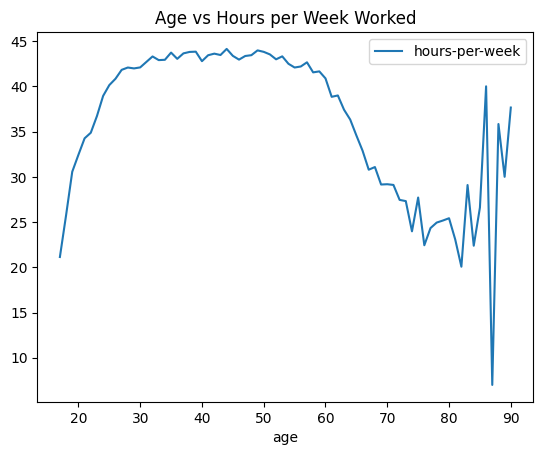

In [148]:
age_vs_work_hours = pd.DataFrame()

age_vs_work_hours["age"] = adults["age"]
age_vs_work_hours["hours-per-week"] = adults["hours-per-week"]

grouped_age_vs_work_hours = age_vs_work_hours.groupby("age").mean().reset_index()
grouped_age_vs_work_hours.plot(x="age", y="hours-per-week", kind="line", title="Age vs Hours per Week Worked")


## Hours worked by marital status 

<Axes: title={'center': 'Marital Status vs Average Hours per Week Worked'}, xlabel='marital-status'>

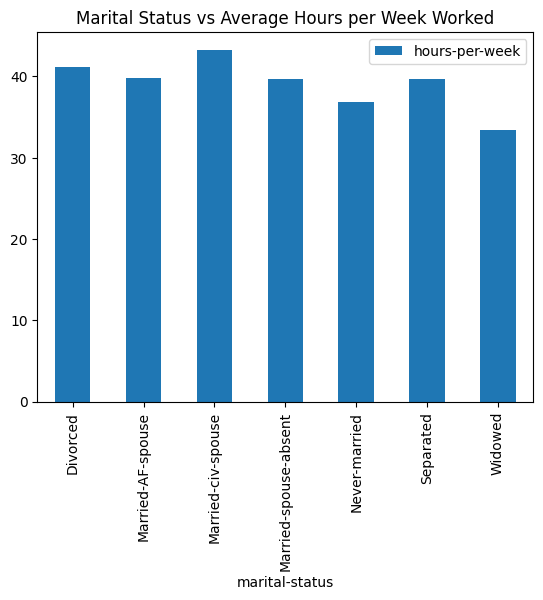

In [149]:
work_hours_by_marital_status = pd.DataFrame()

work_hours_by_marital_status["marital-status"] = adults["marital-status"]
work_hours_by_marital_status["hours-per-week"] = adults["hours-per-week"]

grouped_work_hours_by_marital_status = work_hours_by_marital_status.groupby("marital-status").mean().reset_index()
grouped_work_hours_by_marital_status.plot(x="marital-status", y="hours-per-week", kind="bar", title="Marital Status vs Average Hours per Week Worked")


## Income by sex

<Axes: title={'center': 'Sex vs Number of People Earning >50K'}, xlabel='sex'>

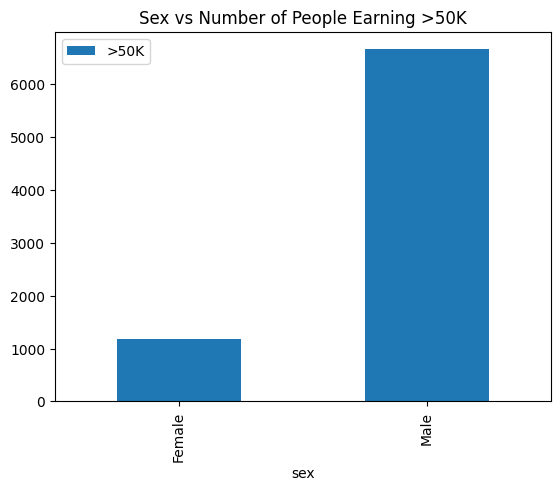

In [150]:
income_by_sex = pd.DataFrame()

income_by_sex["sex"] = adults["sex"]
income_by_sex["income"] = adults["income"]

grouped_income_by_sex = income_by_sex.groupby("sex").value_counts().unstack().reset_index()
grouped_income_by_sex.plot(x="sex", y=">50K", kind="bar", title="Sex vs Number of People Earning >50K")


# Exercise 2

## Exercises

File: "Exercises in DT and EDA"

- Plot the number of Cinemas in Danmark over the years. The next cell loads in the needed data for you if you have the file "DK_cinemas.csv" in the same folder as this notebook. 
- Based on the `Penguins` dataset, answer the following questions:
    - Make a barplot that shows how many penguins there are of each species in the dataset. Support the plot by calculating the numbers.
    - Make a barplot that shows the average body mass for each species of penguin. Support the plot by calculating the numbers
    - Make a boxplots that shows the distribution of the body mass for each species of penguin. Support the plot by calculating the numbers.
    - Make a scatterplot that shows the correlation between body mass (in g) and flipper length (in mm). Support the plot by calculating the numbers.
    - Use boxplots and histograms to show how bill length, bill depth, flipper length and body mass varies between species and sex.
    - Visualise how the linear correlation between body mass and flipper length varies between species and sex.
- Do an exploratory data analysis of the adult dataset. The cell below loads the dataset from UCI Machine Learning Repository into a pandas dataframe called `adult_data`. It requires that you have installed the package `ucimlrepo`. (Otherwise the dataset is on moodle page for this class.)
- Complete an exploratory data analysis of the titanic dataset (it is on moodle). (Remember, you can load it in as `titanic_data = pd.read_csv("titanic_survival_data.csv")`)
- Do an exploratory data analysis of the diabetes dataset. The cell below loads the dataset from the scikit learn package into the pandas dataframe called `diabetes_data`.


## 2.1

<Axes: title={'center': 'Cinemas in Denmark'}, xlabel='Year'>

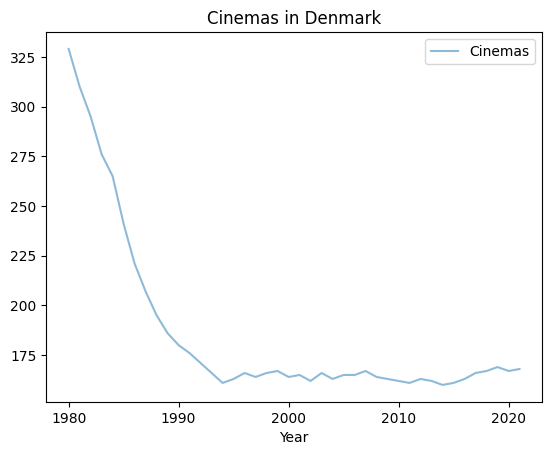

In [151]:
cinemas = pd.read_csv("Data/DK_cinemas.csv", sep=";")

cinemas.plot(x="Year", y="Cinemas", kind="line", title="Cinemas in Denmark", alpha=0.5)

## 2.2

In [152]:
penguins_data = sns.load_dataset("penguins")

penguins_data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


     species  count
0     Adelie    152
1     Gentoo    124
2  Chinstrap     68


<Axes: title={'center': 'Penguin Species Counts'}, xlabel='species'>

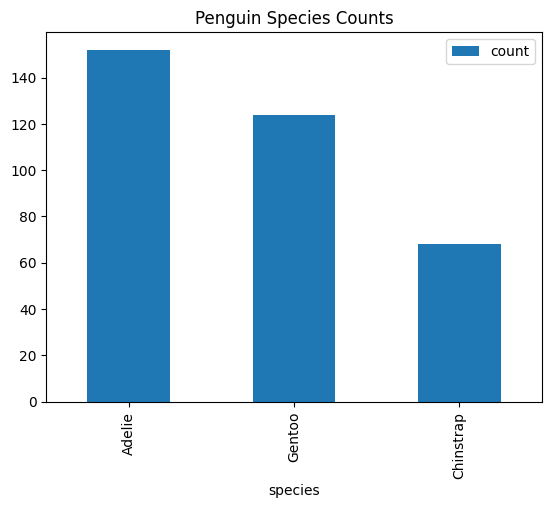

In [153]:
penguin_species = penguins_data["species"].unique()
penguin_species_counts = penguins_data["species"].value_counts().reset_index()

print(penguin_species_counts)
penguin_species_counts.plot(x="species", y="count", kind="bar", title="Penguin Species Counts")

     species  body_mass_g
0     Adelie  3700.662252
1  Chinstrap  3733.088235
2     Gentoo  5076.016260


<Axes: title={'center': 'Average Body Mass of Penguin Species'}, xlabel='species'>

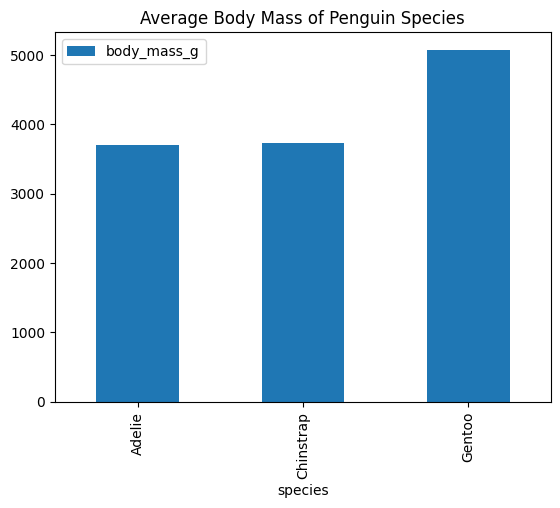

In [154]:
avg_species_bodymass = penguins_data.groupby("species")["body_mass_g"].mean().reset_index()

print(avg_species_bodymass)
avg_species_bodymass.plot(x="species", y="body_mass_g", kind="bar", title="Average Body Mass of Penguin Species")

Averages:
      species  body_mass_g
0     Adelie  3700.662252
1  Chinstrap  3733.088235
2     Gentoo  5076.016260
Medians:
      species  body_mass_g
0     Adelie       3700.0
1  Chinstrap       3700.0
2     Gentoo       5000.0
1st Quartiles:
 

     species  body_mass_g
0     Adelie       3350.0
1  Chinstrap       3487.5
2     Gentoo       4700.0
3rd Quartiles:
      species  body_mass_g
0     Adelie       4000.0
1  Chinstrap       3950.0
2     Gentoo       5500.0


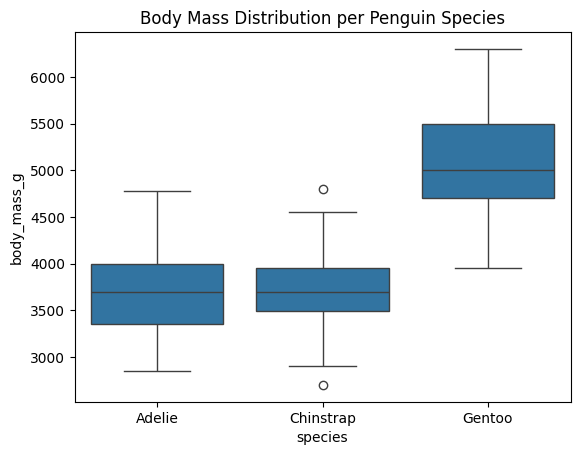

In [155]:
bodymass_distribution_per_species = penguins_data[["species", "body_mass_g"]]

bdps_averages = bodymass_distribution_per_species.groupby("species")["body_mass_g"].mean().reset_index()
bdps_medians = bodymass_distribution_per_species.groupby("species")["body_mass_g"].median().reset_index()
bdps_q1 = bodymass_distribution_per_species.groupby("species")["body_mass_g"].quantile(0.25).reset_index()
bdps_q3 = bodymass_distribution_per_species.groupby("species")["body_mass_g"].quantile(0.75).reset_index()
print("Averages:\n", bdps_averages)
print("Medians:\n", bdps_medians)
print("1st Quartiles:\n", bdps_q1)
print("3rd Quartiles:\n", bdps_q3)

sns.boxplot(x="species", y="body_mass_g", data=bodymass_distribution_per_species)
plt.title("Body Mass Distribution per Penguin Species")
plt.show()

Correlation between Body Mass and Flipper Length:
                    body_mass_g  flipper_length_mm
body_mass_g           1.000000           0.839974
flipper_length_mm     0.839974           1.000000


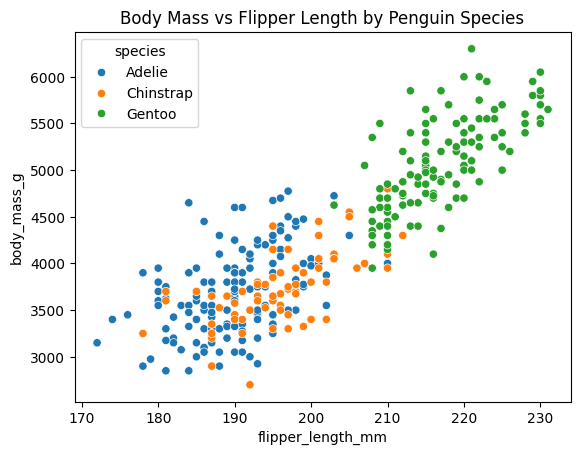

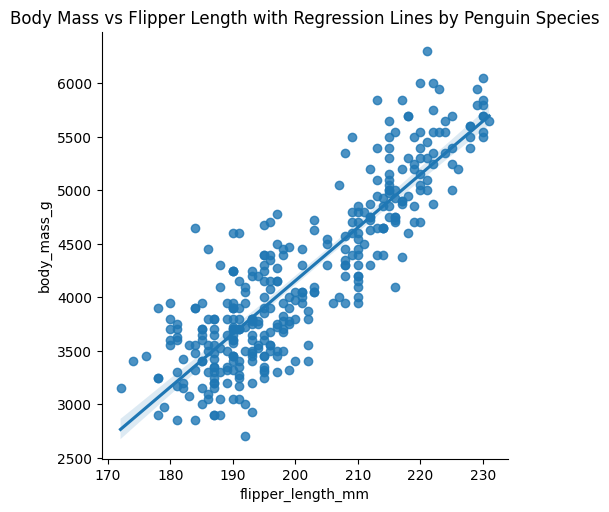

In [156]:
body_mass_to_flipper_length = penguins_data[["body_mass_g", "flipper_length_mm"]]

correlation = body_mass_to_flipper_length.corr('spearman')
print("Correlation between Body Mass and Flipper Length:\n", correlation)

# Fitted graph
sns.scatterplot(x="flipper_length_mm", y="body_mass_g", hue="species", data=body_mass_to_flipper_length.join(penguins_data["species"]))
plt.title("Body Mass vs Flipper Length by Penguin Species")
plt.show()

sns.lmplot(x="flipper_length_mm", y="body_mass_g", data=body_mass_to_flipper_length.join(penguins_data["species"]))
plt.title("Body Mass vs Flipper Length with Regression Lines by Penguin Species")
plt.show()

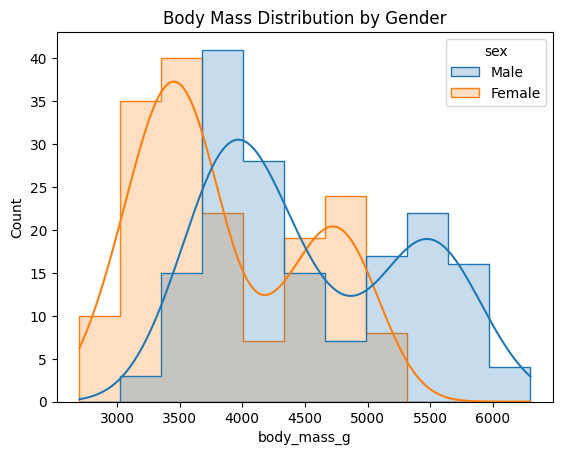

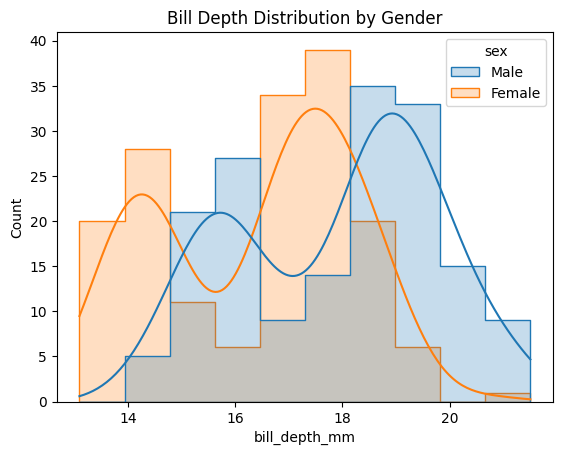

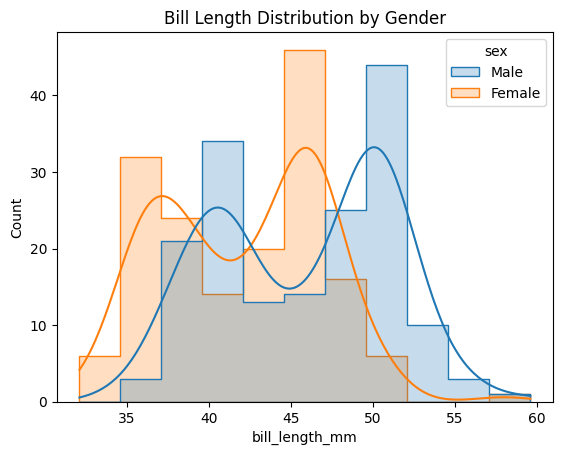

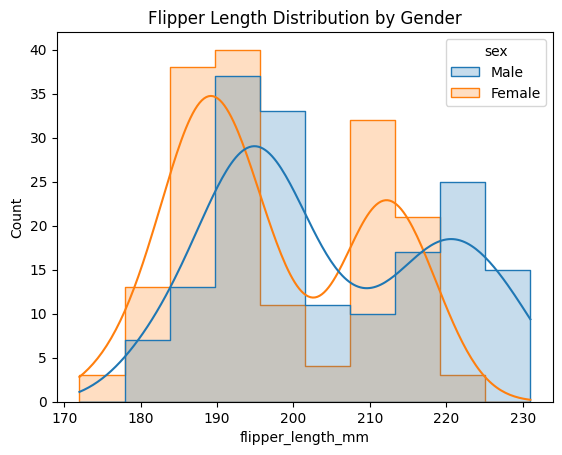

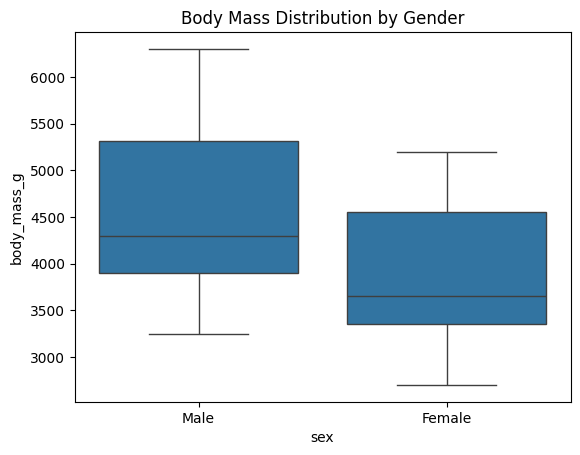

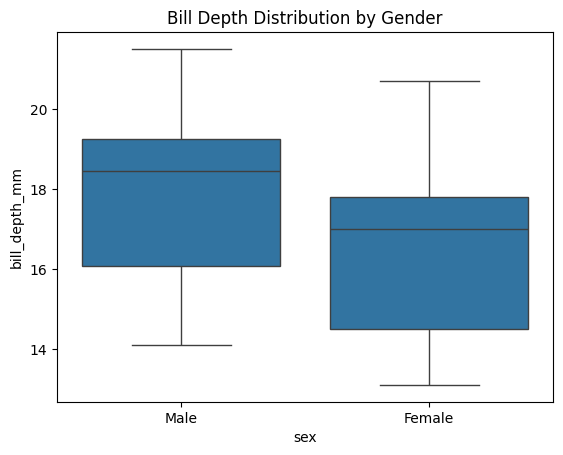

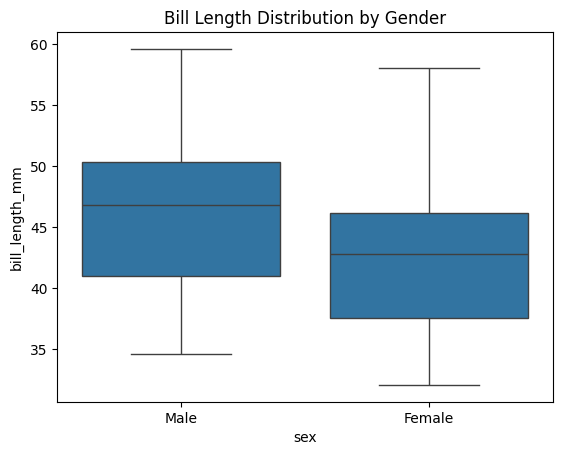

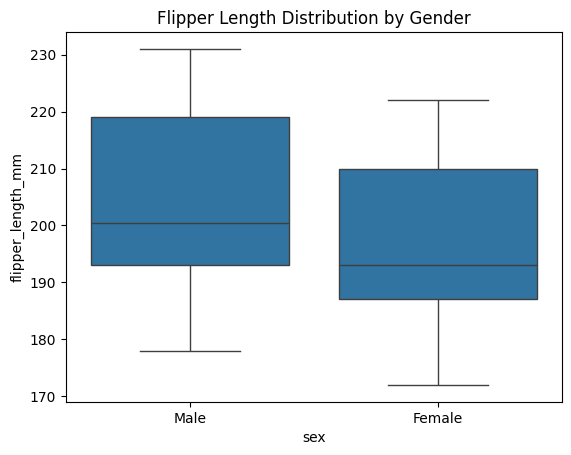

In [157]:
gender_to_bodymass = penguins_data[["sex", "body_mass_g"]]
gender_to_bill_depth = penguins_data[["sex", "bill_depth_mm"]]
gender_to_bill_length = penguins_data[["sex", "bill_length_mm"]]
gender_to_flipper_length = penguins_data[["sex", "flipper_length_mm"]]

# Histograms
sns.histplot(data=gender_to_bodymass, x="body_mass_g", hue="sex", kde=True, element="step")
plt.title("Body Mass Distribution by Gender")
plt.show() 

sns.histplot(data=gender_to_bill_depth, x="bill_depth_mm", hue="sex", kde=True, element="step")
plt.title("Bill Depth Distribution by Gender")
plt.show()

sns.histplot(data=gender_to_bill_length, x="bill_length_mm", hue="sex", kde=True, element="step")
plt.title("Bill Length Distribution by Gender")
plt.show()

sns.histplot(data=gender_to_flipper_length, x="flipper_length_mm", hue="sex", kde=True, element="step")
plt.title("Flipper Length Distribution by Gender")
plt.show()

# Boxplots
sns.boxplot(x="sex", y="body_mass_g", data=gender_to_bodymass)
plt.title("Body Mass Distribution by Gender")
plt.show()

sns.boxplot(x="sex", y="bill_depth_mm", data=gender_to_bill_depth)
plt.title("Bill Depth Distribution by Gender")
plt.show()

sns.boxplot(x="sex", y="bill_length_mm", data=gender_to_bill_length)
plt.title("Bill Length Distribution by Gender")
plt.show()

sns.boxplot(x="sex", y="flipper_length_mm", data=gender_to_flipper_length)
plt.title("Flipper Length Distribution by Gender")
plt.show()

Female Body Mass to Flipper Length Correlation:
                    body_mass_g  flipper_length_mm
body_mass_g           1.000000           0.790429
flipper_length_mm     0.790429           1.000000
Male Body Mass to Flipper Length Correlation:
                    body_mass_g  flipper_length_mm
body_mass_g           1.000000           0.796562
flipper_length_mm     0.796562           1.000000


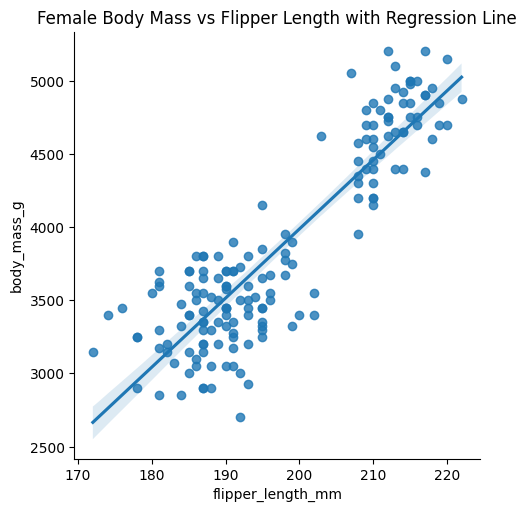

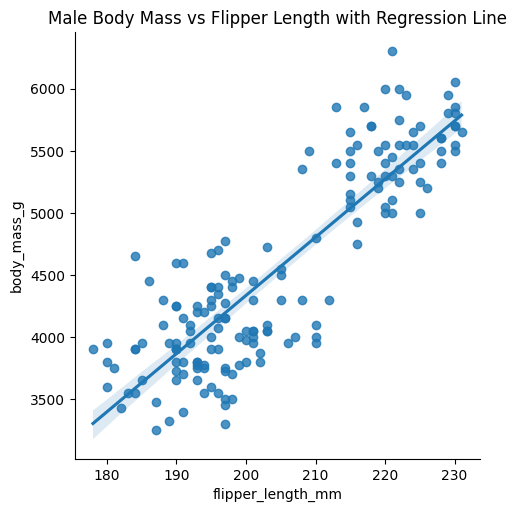

In [158]:
female_bodymass_to_flipper_length = penguins_data[penguins_data["sex"] == "Female"][["body_mass_g", "flipper_length_mm"]]
male_bodymass_to_flipper_length = penguins_data[penguins_data["sex"] == "Male"][["body_mass_g", "flipper_length_mm"]]

female_btfl_correlation = female_bodymass_to_flipper_length.corr('spearman')
male_btfl_correlation = male_bodymass_to_flipper_length.corr('spearman')

print("Female Body Mass to Flipper Length Correlation:\n", female_btfl_correlation)
print("Male Body Mass to Flipper Length Correlation:\n", male_btfl_correlation)

# Fitted graphs
sns.lmplot(x="flipper_length_mm", y="body_mass_g", data=female_bodymass_to_flipper_length)
plt.title("Female Body Mass vs Flipper Length with Regression Line")
plt.show()

sns.lmplot(x="flipper_length_mm", y="body_mass_g", data=male_bodymass_to_flipper_length)
plt.title("Male Body Mass vs Flipper Length with Regression Line")
plt.show()

# Exercise 3

## 3.1

In this exercise we will use the penguins dataset (can be imported using the code `penguins_data = sns.load_dataset("penguins")`)

Please answer the following questions:
1. For the different species of penguins (Adelie, Chinstrap, and Gentoo), how many penguins are there of each species?
2. For the different species of penguins (Adelie, Chinstrap, and Gentoo), is the body mass variable normally distributed?
3. Test whether there is a difference in body mass for Adelie penguins and Chinstrap penguins. Remember to justify your choice of test, clearly state the null hypothesis and alternative hypothesis, and state the significance level you will use. Hint: If your test give `nan` values you might need to drop missing values with the `dropna` method.
4. Test whether there is a difference in body mass for Chinstrap penguins and Gentoo penguins. Remember to justify your choice of test, clearly state the null hypothesis and alternative hypothesis, and state the significance level you will use. Hint: If your test give `nan` values you might need to drop missing values with the `dropna` method.

     species  count
0     Adelie    152
1     Gentoo    124
2  Chinstrap     68


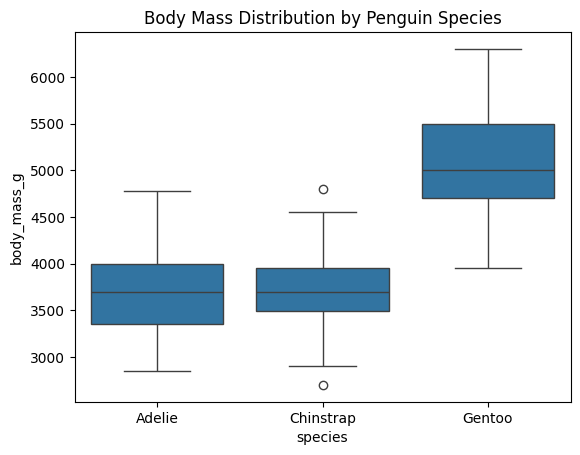

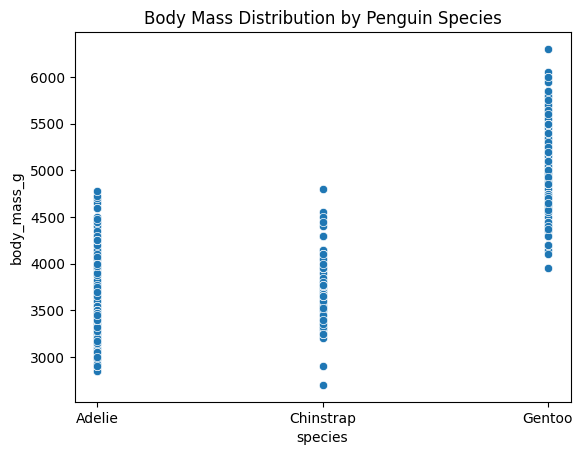

In [159]:
amount_penguins_per_species = penguins_data["species"].value_counts().reset_index()
amount_penguins_per_species.columns = ["species", "count"]
print(amount_penguins_per_species)

sns.boxplot(x="species", y="body_mass_g", data=penguins_data)
plt.title("Body Mass Distribution by Penguin Species")
plt.show()

# Scatterplot of body mass distribution by species
sns.scatterplot(x="species", y="body_mass_g", data=penguins_data)
plt.title("Body Mass Distribution by Penguin Species")
plt.show()

We assume that that both body-masses are normally distributed

In [160]:
adelie_penguins = penguins_data[penguins_data["species"] == "Adelie"]
chinstrap_penguins = penguins_data[penguins_data["species"] == "Chinstrap"]

statistic, p_value = stats.shapiro(adelie_penguins["body_mass_g"].dropna())
print("Shapiro-Wilk Test for Adelie Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)

statistic, p_value = stats.shapiro(chinstrap_penguins["body_mass_g"].dropna())
print("Shapiro-Wilk Test for Chinstrap Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)

# Seeing as the p-value for Adelie penguins is more than 0.05, we fail to reject the null hypothesis,l.

Shapiro-Wilk Test for Adelie Penguins Body Mass:
T-statistic: 0.9807078507062791
P-value: 0.03239702501305105
Shapiro-Wilk Test for Chinstrap Penguins Body Mass:
T-statistic: 0.984493761674102
P-value: 0.5605082387697975


We see that Chinstrap penguins are likely normally distributed, but Adelie are not. Thus we use a Mann-Whitney U test.

H₀: There is no difference in body mass between Adelie and Chinstrap penguins
    (μ_Adelie = μ_Chinstrap)

H₁: There is a difference in body mass between Adelie and Chinstrap penguins
    (μ_Adelie ≠ μ_Chinstrap)

α = 0.05

In [161]:
u_statistic, p_value_u = stats.mannwhitneyu(adelie_penguins["body_mass_g"].dropna(), chinstrap_penguins["body_mass_g"].dropna())
print("Mann-Whitney U Test between Adelie and Chinstrap Penguins Body Mass:")
print("U-statistic:", u_statistic)
print("P-value:", p_value_u)


Mann-Whitney U Test between Adelie and Chinstrap Penguins Body Mass:
U-statistic: 4831.0
P-value: 0.4854772721011861


From the result we see that there is no difference in boy mass between the two penguin species.

Comparing Chinstrap and Gentoo we again assume the two sets are normally distributed, knowing that Chinstrap is, we test for Gentoo.

In [162]:
gentoo_penguins = penguins_data[penguins_data["species"] == "Gentoo"]

statistic, p_value = stats.shapiro(gentoo_penguins["body_mass_g"].dropna())
print("Shapiro-Wilk Test for Gentoo Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)



Shapiro-Wilk Test for Gentoo Penguins Body Mass:
T-statistic: 0.9859276066609362
P-value: 0.23361648888961845


With a p-value well above 0.05, gentoo penguins are likely normally distributed, so we use a t-test.

H₀: There is no difference in body mass between Gentoo and Chinstrap penguins
    (μ_Gentoo = μ_Chinstrap)

H₁: There is a difference in body mass between Gentoo and Chinstrap penguins
    (μ_Gentoo ≠ μ_Chinstrap)

α = 0.05

In [163]:
statistic, p_value = stats.ttest_ind(gentoo_penguins["body_mass_g"].dropna(), chinstrap_penguins["body_mass_g"].dropna())
print("T-Test between Gentoo and Chinstrap Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", round(p_value, 50))


T-Test between Gentoo and Chinstrap Penguins Body Mass:
T-statistic: 19.103227243520955
P-value: 5.2661999999999995e-46


Seeing as the the p-value of our t-test is very well below 0.05, it would strongly suggest that there is a difference in the bodymass of Gentoo and Chinstrap penguins, thus rejecting the null hyphothesis.

## 3.2

Load in the "fb_like_and_share.csv" data and answer the following questions:

1. Is there a difference in the distribution of likes for photos and videos? Justify your choice of test(s).
2. Is there a difference in the distribution of share counts for photos and videos? Justify your choice of test(s).
3. Perform an ANOVA test to test if there is a difference in means across type of posts for shares. Does it make sense to perform this ANOVA test?
4. Is there actually a statistical significant difference in the distribution of share counts for any two groups?

In [164]:
fb_like_and_share = pd.read_csv("Data/fb_like_and_share.csv", sep=";")
fb_like_and_share.head()

,type,likes_count_fb,shares_count_fb
0,video,577,7
1,photo,2802,23
2,video,490,14
3,link,535,16
4,photo,1049,44


In [165]:
fb_photos = fb_like_and_share[fb_like_and_share["type"] == "photo"]
fb_videos = fb_like_and_share[fb_like_and_share["type"] == "video"]

print("Facebook Photos Data:")
print(fb_photos)
print("Facebook Videos Data:")
print(fb_videos)

Facebook Photos Data:
     type  likes_count_fb  shares_count_fb
1   photo            2802               23
4   photo            1049               44
5   photo            1557               85
6   photo             838                1
8   photo             100                1
10  photo            1258               19
11  photo             487                5
12  photo             184               12
14  photo             653               43
19  photo             637                3
26  photo            1544               47
27  photo             320                0
28  photo             329                3
Facebook Videos Data:
     type  likes_count_fb  shares_count_fb
0   video             577                7
2   video             490               14
9   video             112                3
13  video            1051               78
17  video              35                0
20  video             116                1
22  video             175                0
30  video 

We begin by assuming both sets are normally distributed, with an α = 0.05

In [166]:
statistic, p_value = stats.shapiro(fb_photos["likes_count_fb"].dropna())
print("Shapiro-Wilk Test for Facebook Photos Like Count:")
print("T-statistic:", statistic)
print("P-value:", p_value) 

statistic, p_value = stats.shapiro(fb_videos["likes_count_fb"].dropna())
print("Shapiro-Wilk Test for Facebook Videos Like Count:")
print("T-statistic:", statistic)
print("P-value:", p_value)

Shapiro-Wilk Test for Facebook Photos Like Count:
T-statistic: 0.8774655646725982
P-value: 0.06589939260226885
Shapiro-Wilk Test for Facebook Videos Like Count:
T-statistic: 0.8477493538641958
P-value: 0.07038250110283344


Seeing values above 0.05 for both data sets, we can see that the data is normally distributed with some deviation. This does not reject our null hypothesis, so we can use a t-test to check for differences in like counts between sets with the following hypothesis:

H₀: There is no difference between like counts 
    (μ_Photos = μ_Videos)

H₁: There is a difference between like counts 
    (μ_Photos ≠ μ_Videos)

α = 0.05

In [167]:
statistics, p_value = stats.ttest_ind(fb_photos["likes_count_fb"].dropna(), fb_videos["likes_count_fb"].dropna())

print("T-Test between Facebook Photos and Videos Like Count:")
print("T-statistic:", statistics)
print("P-value:", p_value)


T-Test between Facebook Photos and Videos Like Count:
T-statistic: 2.125454058083514
P-value: 0.04619850270741723


Looking at the p-value of our test, we have a value of 0.046, which is below the significance level, rejecting our null hyphothesis as there's a somewhat strong indication of a difference in like counts between the two sets.

# Exercise 5

## 5.1

Load in the "EnergyEfficiency.csv" data (on Moodle). It is data about energy efficiency of buildings, more specifically it is about predicting the heating load and cooling load of building based on a set of features about the buildings. It is retrieved from UCI Machine Learning Repository: [Energy efficiency](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

Answer the following questions:
1. Do a visualization of the relationship/correlation between the variables `SurfaceArea` and `HeatingLoad`, with `HeatingLoad` as the dependent variable (y variable).
2. Is there a correlation between `SurfaceArea` and `HeatingLoad`? If so, what is the strength of it, and is it statistically significant? Does this make sense to you, if `SurfaceArea` is the surface area of a building and the `HeatingLoad` is how much energy it takes to heat up the building?
3. Add `hue = "OverallHeight"` to the scatterplot you did as an answer to question 1. Assuming that `OeverallHeight` represent the height of the building, does it change your answer to the last question of 2?
4. Train a simple linear regression model with `SurfaceArea` as independent variable (x) and `HeatingLoad` as dependent variable (y).
5. What does the model say about the change in `HeatingLoad` when the `SurfaceArea` goes up by 1 unit?
6. Add the linear regression line to a scatterplot of `SurfaceArea` and `HeatingLoad`.
7. Evaluate how good your simple linear regression model is. Hint: Chose one or several measures to evaluate your model.
8. Subset your data such that you only have houses with "OverallHeight=7" and train a new simple linear regression model with `SurfaceArea` as independent variable and `HeatingLoad` as dependent variable. How good is this model compared to the on trained on the full dataset?

In [168]:
data = pd.read_csv("Data/EnergyEfficiency.csv")
data.head()

,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution,HeatingLoad,CoolingLoad
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


Correlation between Surface Area and Heating Load: -0.6221346966316251


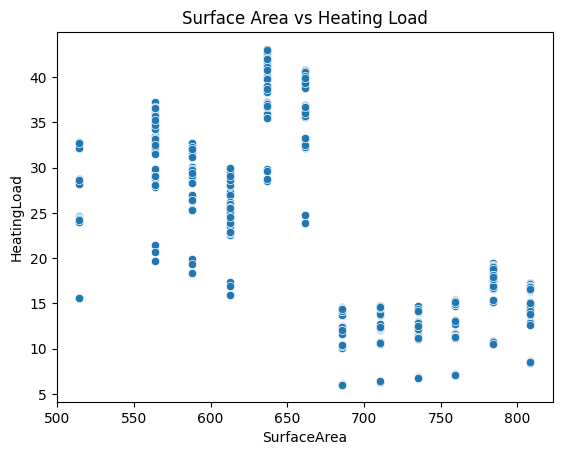

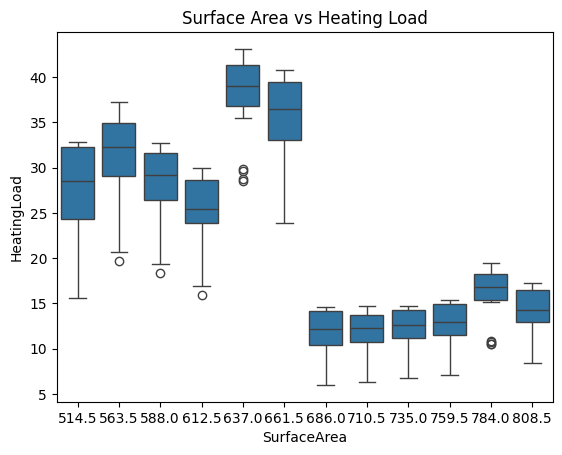

In [169]:
SurfaceArea = data["SurfaceArea"]

HeatingLoad = data["HeatingLoad"]

correlation = SurfaceArea.corr(HeatingLoad, method='spearman')
print("Correlation between Surface Area and Heating Load:", correlation)

sns.scatterplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load")
plt.show()

sns.boxplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load")
plt.show()

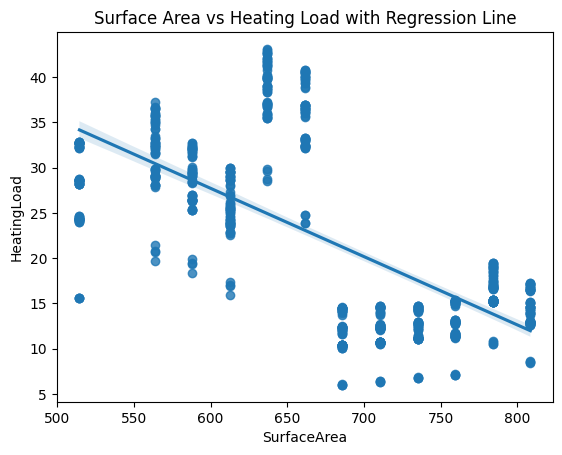

In [170]:
sns.regplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load with Regression Line")
plt.show()

In [171]:
# Add constant term (intercept) properly
X = sm.add_constant(SurfaceArea)

# Verify the relationship first
print("Correlation:", SurfaceArea.corr(HeatingLoad))
print("\nFirst few values:")
print("SurfaceArea:", SurfaceArea.head().values)
print("HeatingLoad:", HeatingLoad.head().values)

linreg_statsm = sm.OLS(HeatingLoad, X).fit()

Correlation: -0.6581202267776216

First few values:
SurfaceArea: [514.5 514.5 514.5 514.5 563.5]
HeatingLoad: [15.55 15.55 15.55 15.55 20.84]


In [172]:
linreg_statsm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            HeatingLoad   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     585.3
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           1.69e-96
Time:                        10:36:01   Log-Likelihood:                -2646.6
No. Observations:                 768   AIC:                             5297.
Df Residuals:                     766   BIC:                             5306.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          72.9454      2.111     34.554      0.000      68.801      77.090
SurfaceArea    -0.0754      0.003    -24.192      0.000      -0.082      -0.069
==============================================================================
Omnibus:                       37.973   Durbin-Watson:                   0.321
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               42.851
Skew:                           0.576   Prob(JB):                     4.95e-10
Kurtosis:                       2.890   Cond. No.                     5.21e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.21e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [173]:
(print(linreg_statsm.rsquared))

0.433122232893828


In [174]:
print(linreg_statsm.rsquared_adj)

0.43238218358951186


In [175]:
# MAE

print(np.mean(np.abs(linreg_statsm.resid)))

# MSE

print(np.mean(linreg_statsm.resid**2))

6.002338517195692
57.63983779426345


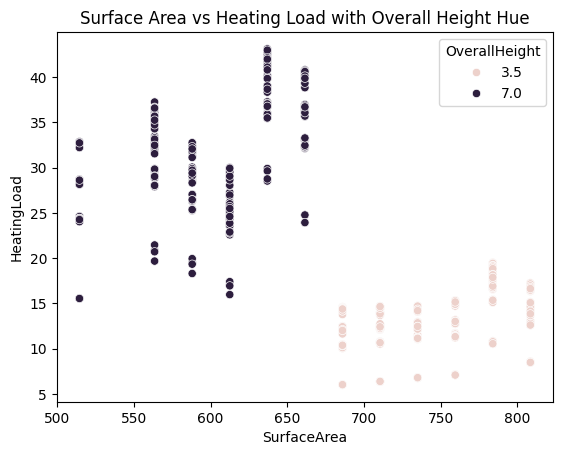

In [176]:
sns.scatterplot(x="SurfaceArea", y="HeatingLoad", hue="OverallHeight", data=data)
plt.title("Surface Area vs Heating Load with Overall Height Hue")
plt.show()

In [177]:
b = linreg_statsm.params

print(b)

const          72.945382
SurfaceArea    -0.075387
dtype: float64


# Exercise 6

## 6.1

1. Load the [dataset](https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset) from Kaggle. Use the "hour.csv" file.
2. Visualize the structure of the dataset using appropriate libraries and plots.
3. Clean and pre-process the dataset as required and prepare the data for modelling.
4. Create the lag and rolling windows features for the "cnt" column such as: 1 day lag, 1 week lag, 1 month, etc. and last 3 day rolling mean, last 3 hours rolling mean, etc. But it should be based on your dataset and what makes sense for this dataset.
5. Implement linear regression to predict how many bikes will be rented each hour of the last week and evaluate using appropriate metrics.
6. Implement XGBoost to predict how many bikes will be rented each hour of the last week and evaluate using appropriate metrics.
7. Experiment with predicting different time periods, such as use all data to predict bike rentals for just the next day (24 hours) or the next entire month and then see how much better or worse the model gets
8. Experiment tuning hyperparameters

In [178]:
# Download dataset
path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")

print("Path to dataset files:", path)

# Load the dataset
files = os.listdir(path)
print("Files in dataset:", files)

# Load the hourly data (typically the main file)
hour = pd.read_csv(os.path.join(path, "hour.csv"))

print("First 5 records:")
hour.head()

Path to dataset files: /home/xilas/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1
Files in dataset: ['hour.csv', 'Readme.txt', 'day.csv']
First 5 records:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


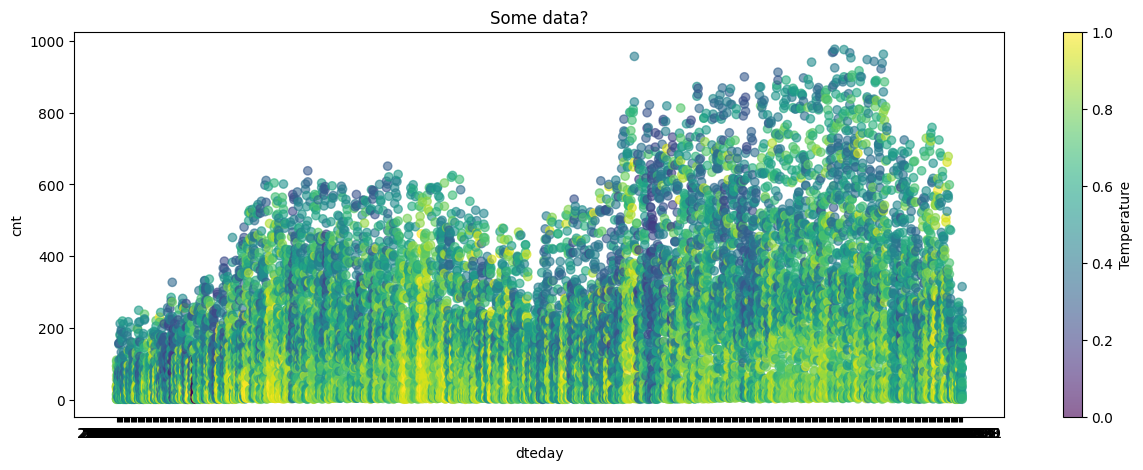

In [179]:
plt.figure(figsize=(15, 5))
plt.scatter(hour["dteday"], hour["cnt"], c=hour["hum"], cmap="viridis", alpha=0.6)
plt.colorbar(label="Temperature")
plt.xlabel("dteday")
plt.ylabel("cnt")
plt.title("Some data?")
plt.show()

In [180]:
hour["datetime_obj"] = pd.to_datetime(hour["dteday"])
hour["Day"] = hour["datetime_obj"].dt.hour
hour["Week"] = hour["datetime_obj"].dt.dayofweek
hour["Month"] = hour["datetime_obj"].dt.month
hour["Year"] = hour["datetime_obj"].dt.year

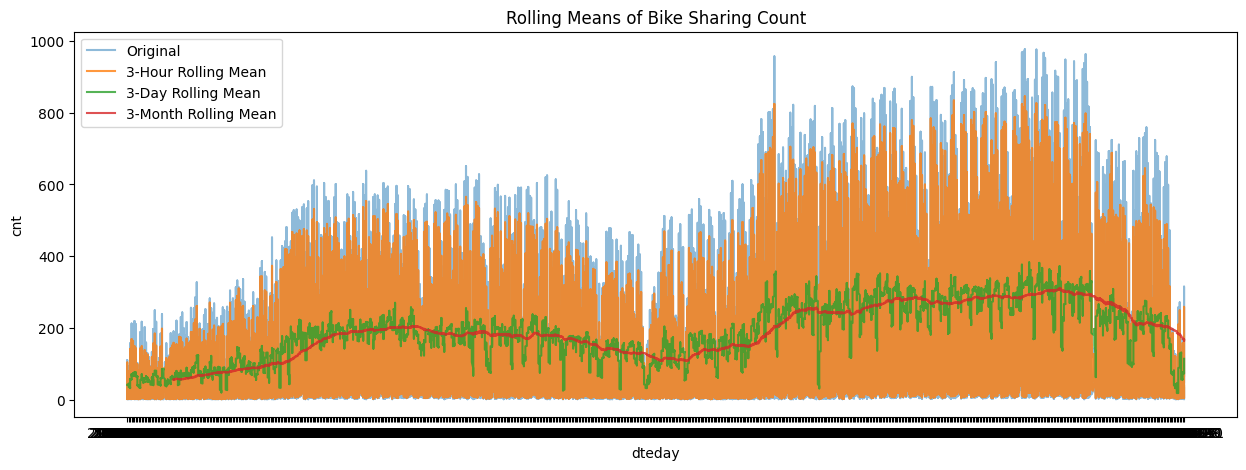

In [181]:
last_3_hour_rolling_mean = hour["cnt"].rolling(window=3).mean()
last_3_day_rolling_mean = hour["cnt"].rolling(window=24).mean()
last_3_month_rolling_mean = hour["cnt"].rolling(window=24*30).mean()

plt.figure(figsize=(15, 5))
plt.plot(hour["dteday"], hour["cnt"], label="Original", alpha=0.5)
plt.plot(hour["dteday"], last_3_hour_rolling_mean, label="3-Hour Rolling Mean", alpha=0.8)
plt.plot(hour["dteday"], last_3_day_rolling_mean, label="3-Day Rolling Mean", alpha=0.8)
plt.plot(hour["dteday"], last_3_month_rolling_mean, label="3-Month Rolling Mean", alpha=0.8)
plt.xlabel("dteday")
plt.ylabel("cnt")
plt.title("Rolling Means of Bike Sharing Count")
plt.legend()
plt.show()

# Exercise 7

## 7.1

In this exercise, we will use the titanic dataset to build a KNN classifier for the target variable `Survived`. In this exercise, all the necessary steps are broken down into small individual task you should do. So, do the following tasks:

1. Load in the titanic dataset (on Moodle as "titanic_survival_data.csv"), select the columns "Pclass", "Sex", "Age", and "Fare" for the feature set X and "Survived" for the target variable y.
2. For the columns "Age" and "Fare", replace the missing values with the column's mean.
3. Turn the variables "Pclass" and "Sex" into dummy variables.
4. Do a train-test split of the data with 20% for testing. Use random state 962.
5. Scale the X training dataset, using the standard scaler.
6. Transform the X test dataset with the same scaler fitted in task 5.
7. Train KNN models for multiple K's
8. Train KNN models for K from 2 to 50 and plot the train and test precision and recall.
9. Select the K above 5 with the highest precision and the K above 5 with the highest recall and retrain two models for these values of K
10. For the two models trained in 9, create the confusion matrix and calculate, accuracy precision recall, and f-1 score.

In [182]:
data = pd.read_csv("Data/titanic_survival_data.csv")
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.250,S
1,1,1,female,38.0,1,0,712.833,C
2,1,3,female,26.0,0,0,7.925,S
3,1,1,female,35.0,1,0,53.100,S
4,0,3,male,35.0,0,0,8.050,S


In [183]:
X = data[["Pclass", "Sex", "Age","Fare"]]
Y = data["Survived"]

# Clean Age and Fare columns by filling missing values with the mean
X["Age"] = X["Age"].fillna(X["Age"].mean())
X["Fare"] = X["Fare"].fillna(X["Fare"].mean())

# Get dummies for non numerical columns
X = pd.get_dummies(X, columns=["Sex","Pclass"],)

X.head()


,Age,Fare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
0,22.0,7.250,False,True,False,False,True
1,38.0,712.833,True,False,True,False,False
2,26.0,7.925,True,False,False,False,True
3,35.0,53.100,True,False,True,False,False
4,35.0,8.050,False,True,False,False,True


In [184]:
X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(X, Y, test_size=0.2, random_state=962)

In [198]:
scalar = sklearn.preprocessing.StandardScaler()
X_train_scaled = pd.DataFrame(scalar.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scalar.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,Age,Fare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
109,-0.001709,-0.417652,1.389259,-1.389259,-0.575188,-0.520988,0.926827
622,-0.749967,0.432741,-0.719808,0.719808,-0.575188,-0.520988,0.926827
789,1.259968,-0.066371,-0.719808,0.719808,1.738562,-0.520988,-1.078950
562,-0.131525,-0.485611,-0.719808,0.719808,-0.575188,1.919430,-1.078950
75,-0.363441,-0.522940,-0.719808,0.719808,-0.575188,-0.520988,0.926827


In [186]:
# Train KNN models for k from 2 to 50
k_values = range(2, 51)
train_accuracies = []
test_accuracies = []
train_precisions = []
test_precisions = []
train_recalls = []
test_recalls = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, Y_train)
    
    Y_train_pred = knn.predict(X_train_scaled)
    Y_test_pred = knn.predict(X_test_scaled)
    
    train_accuracies.append(accuracy_score(Y_train, Y_train_pred))
    test_accuracies.append(accuracy_score(Y_test, Y_test_pred))
    
    train_precisions.append(precision_score(Y_train, Y_train_pred))
    test_precisions.append(precision_score(Y_test, Y_test_pred))
    
    train_recalls.append(recall_score(Y_train, Y_train_pred))
    test_recalls.append(recall_score(Y_test, Y_test_pred))

print(f"Training complete for k = 2 to 50")

Training complete for k = 2 to 50


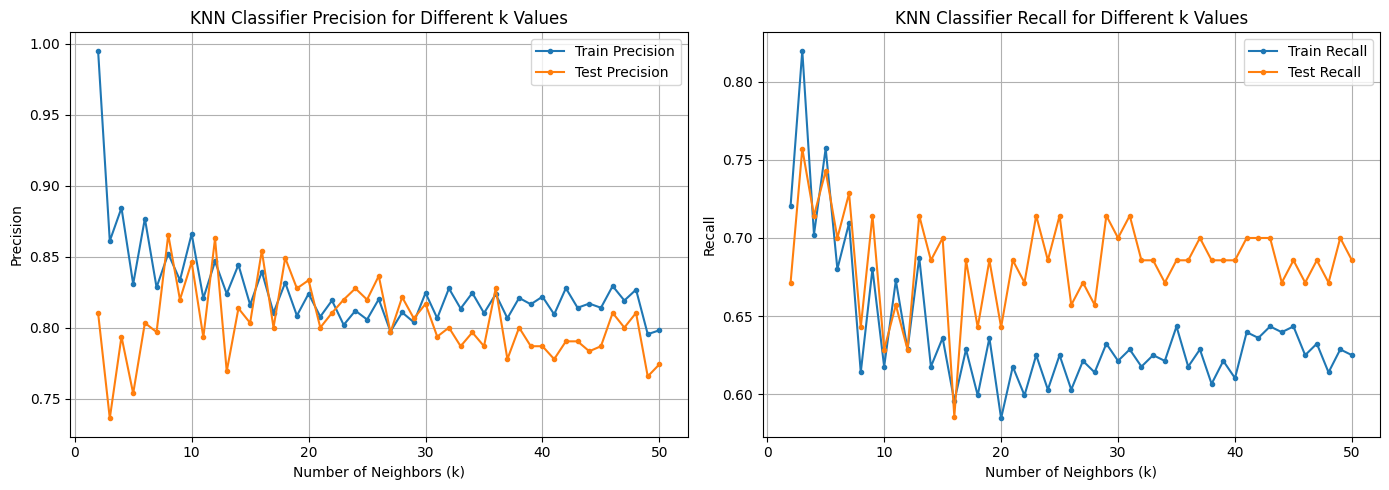

In [187]:
# Plot train and test precision and recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision plot
axes[0].plot(k_values, train_precisions, marker='o', label='Train Precision', markersize=3)
axes[0].plot(k_values, test_precisions, marker='o', label='Test Precision', markersize=3)
axes[0].set_xlabel('Number of Neighbors (k)')
axes[0].set_ylabel('Precision')
axes[0].set_title('KNN Classifier Precision for Different k Values')
axes[0].legend()
axes[0].grid()

# Recall plot
axes[1].plot(k_values, train_recalls, marker='o', label='Train Recall', markersize=3)
axes[1].plot(k_values, test_recalls, marker='o', label='Test Recall', markersize=3)
axes[1].set_xlabel('Number of Neighbors (k)')
axes[1].set_ylabel('Recall')
axes[1].set_title('KNN Classifier Recall for Different k Values')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

In [188]:
# Find best k for precision and recall (k > 5)
best_precision_k = list(k_values)[np.argmax(test_precisions[4:])] + 4  # offset by 4 since we skip k=2,3,4,5
best_recall_k = list(k_values)[np.argmax(test_recalls[4:])] + 4

print(f"Best k for precision (k > 5): {best_precision_k} with precision = {max(test_precisions[4:]):.4f}")
print(f"Best k for recall (k > 5): {best_recall_k} with recall = {max(test_recalls[4:]):.4f}")

Best k for precision (k > 5): 8 with precision = 0.8654
Best k for recall (k > 5): 7 with recall = 0.7286


In [189]:
# Train final models with best k values
knn_best_precision = KNeighborsClassifier(n_neighbors=best_precision_k)
knn_best_precision.fit(X_train_scaled, Y_train)

knn_best_recall = KNeighborsClassifier(n_neighbors=best_recall_k)
knn_best_recall.fit(X_train_scaled, Y_train)

print(f"Models trained for k={best_precision_k} (best precision) and k={best_recall_k} (best recall)")

Models trained for k=8 (best precision) and k=7 (best recall)


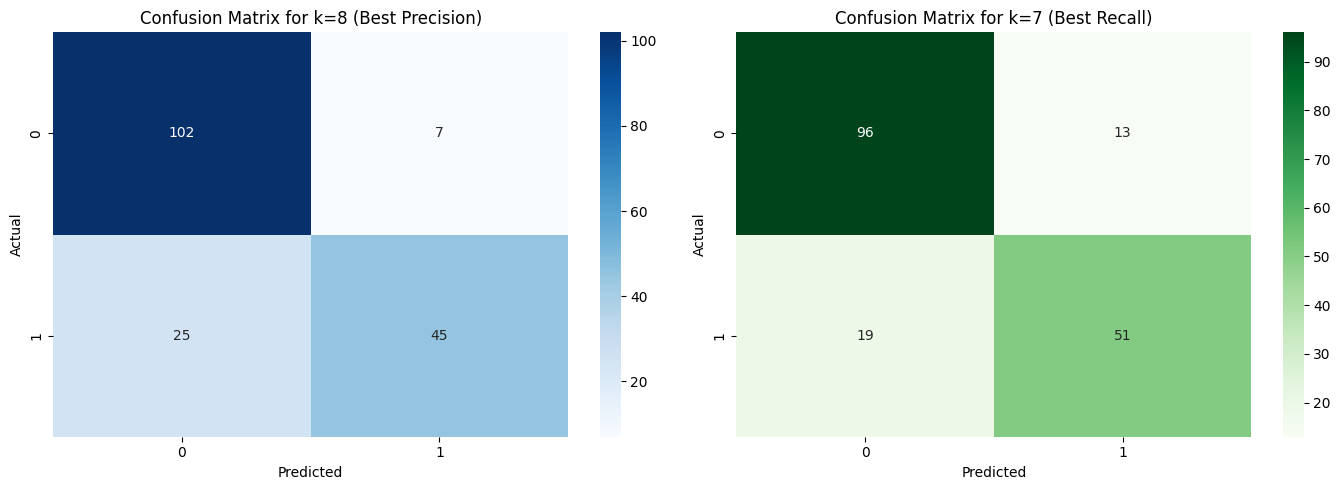

In [191]:
# Condusion matrix

Y_test_pred_precision = knn_best_precision.predict(X_test_scaled)
Y_test_pred_recall = knn_best_recall.predict(X_test_scaled)

cm_precision = confusion_matrix(Y_test, Y_test_pred_precision)
cm_recall = confusion_matrix(Y_test, Y_test_pred_recall)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_precision, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix for k={best_precision_k} (Best Precision)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')  
sns.heatmap(cm_recall, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Confusion Matrix for k={best_recall_k} (Best Recall)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()
